In [1]:
# TODO copy as "Ecell Fusion 2023-01-19" when more complete
# TODO remove dataset specific text when making finalized template

In [1]:
# Full notebook time profiling
from datetime import datetime
start_dt = datetime.now()

In [2]:
# Importing needed code

from pathlib import Path
from typing import Callable, Literal
from datetime import datetime, time, date, timedelta
from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.arc_paths import get_parq_root, get_report_root
from data_processing.dataframe_validation import DataframeColumn
from data_processing.loading.dataframe_loading import load_psd
from data_processing.loading.timetag_processing import (
    calculate_timetag_hours, 
    calculate_event_time
)
from data_processing.processing.bimodal_fitting import (
    get_psd_energy_histogram, 
    scan_histogram_slices
)
from data_processing.processing.neutron_classification import (
    generate_nasa_neutron_window,
    classify
)
from data_processing.reporting.plotting import plot_classification,plot_tail_vs_total, plot_psd_histogram, plot_scatter
# from data_processing.processing.figure_of_merit import ( 
#     FOM, 
#     gaussian, 
#     bimodal
# )

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from mpl_toolkits.mplot3d import Axes3D


# Inputs

In [3]:
all_exp_details = {
    
    "ID-195": "Cu target Used"

}
experiment_neutron_data = {exp_name:load_psd(exp_name) 
                            for exp_name in all_exp_details}


In [4]:
psd_report = experiment_neutron_data["ID-195"]
psd_report.head()

,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total
0,0.209220,253,295,3019850358,0.142373
1,0.487445,617,693,5006080740,0.109668
2,0.324526,403,460,5416645121,0.123913
3,0.887861,1136,1265,10860271270,0.101976
4,0.434292,544,617,32912925403,0.118314


In [212]:
di = pd.read_excel('/home/aeshkeva/project/input_data/ID-124/raw_data/RAW//ID124-I.xlsx')
#di = di.iloc[:3700]

# Remove the first 5 data points from the 'di' DataFrame
#di = di.iloc[5:]  # Adjust the number 5 as needed to remove the desired number of points

di.head()






,Time,Volatge(V),Current(mA)
0,31-Aug-23-13:19:33,1967,0.511
1,31-Aug-23-13:19:34,1999,0.510
2,31-Aug-23-13:19:35,2000,0.511
3,31-Aug-23-13:19:36,2000,0.512
4,31-Aug-23-13:19:37,2001,0.512


In [213]:
window_size = 5  # Adjust this value based on your data and desired level of smoothing

# Apply the moving average smoothing using the rolling() function
# 'window' specifies the window size, and 'min_periods' sets the minimum number of non-NA/null values required in the window
di['smoothed_current'] = di['Current(mA)'].rolling(window=window_size, min_periods=1).mean()

di.head()


,Time,Volatge(V),Current(mA),smoothed_current
0,31-Aug-23-13:19:33,1967,0.511,0.511000
1,31-Aug-23-13:19:34,1999,0.510,0.510500
2,31-Aug-23-13:19:35,2000,0.511,0.510667
3,31-Aug-23-13:19:36,2000,0.512,0.511000
4,31-Aug-23-13:19:37,2001,0.512,0.511200


In [215]:
dp = pd.read_csv('/home/aeshkeva/project/input_data/ID-124/raw_data/RAW//ID124-P.csv')
#dp = dp.iloc[:3700]

dp.head()


,Time,EDWRG Pressure (Torr),CCPG Pressure (Torr)
0,8/31/2023 13:19,0.000144,3.470000e-12
1,8/31/2023 13:19,0.000144,3.470000e-12
2,8/31/2023 13:19,0.000146,3.470000e-12
3,8/31/2023 13:19,0.000145,3.470000e-12
4,8/31/2023 13:19,0.000146,3.470000e-12


In [216]:
window_size = 5  # Adjust this value based on your data and desired level of smoothing

# Apply the moving average smoothing using the rolling() function
# 'window' specifies the window size, and 'min_periods' sets the minimum number of non-NA/null values required in the window
dp['smoothed_pressure'] = dp['EDWRG Pressure (Torr)'].rolling(window=window_size, min_periods=1).mean()

dp.head()

,Time,EDWRG Pressure (Torr),CCPG Pressure (Torr),smoothed_pressure
0,8/31/2023 13:19,0.000144,3.470000e-12,0.000144
1,8/31/2023 13:19,0.000144,3.470000e-12,0.000144
2,8/31/2023 13:19,0.000146,3.470000e-12,0.000145
3,8/31/2023 13:19,0.000145,3.470000e-12,0.000145
4,8/31/2023 13:19,0.000146,3.470000e-12,0.000145


In [151]:
#dp = np.array(dp)
#arr_time = []

#for j in range(len(df)):
#    arr_time.append(j)

In [152]:
#x = arr_time
#y = dp[:,1]

In [153]:
#plt.figure()
#plt.errorbar(x, y)
#plt.show()

In [154]:
di['Current(mA)']

0       0.341
1       0.232
2       0.351
3       0.234
4       0.345
        ...  
3722    0.000
3723    0.000
3724    0.000
3725    0.000
3726    0.000
Name: Current(mA), Length: 3727, dtype: float64

In [155]:
dp['EDWRG Pressure (Torr)']

0       0.000146
1       0.000148
2       0.000146
3       0.000145
4       0.000144
          ...   
4304    0.000127
4305    0.000127
4306    0.000128
4307    0.000128
4308    0.000127
Name: EDWRG Pressure (Torr), Length: 4309, dtype: float64

# Load Data

In [5]:
%%time
psd_report = calculate_timetag_hours(psd_report)
print(f"Dataset size: {psd_report.shape[0]:,} rows")
psd_report.head()
#psd_report.iloc[2000:3000, :]

Dataset size: 879,035 rows
CPU times: total: 0 ns
Wall time: 5 ms


,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total,TIMETAG_HOURS
0,0.209220,253,295,3019850358,0.142373,8.388473e-07
1,0.487445,617,693,5006080740,0.109668,1.390578e-06
2,0.324526,403,460,5416645121,0.123913,1.504624e-06
3,0.887861,1136,1265,10860271270,0.101976,3.016742e-06
4,0.434292,544,617,32912925403,0.118314,9.142479e-06


In [6]:
#max_timetag = psd_report["TIMETAG"].max()
#total_time = max_timetag * 1e-12 # s
#print(f"Total events = {psd_report.shape[0]}")
#print(f"Total time = {total_time:.3f}s")

In [157]:
#print(psd_report)


In [7]:
# Display dataset stats
max_timetag = psd_report["TIMETAG"].max()
total_time = max_timetag * 1e-12 # s

# Remove 130 seconds from the beginning
removed_time = 130  # seconds
total_time -= removed_time

# Filter the dataset to remove events within the first 130 seconds
psd_report = psd_report[psd_report["TIMETAG"] >= removed_time * 1e12]

print(f"Total events = {psd_report.shape[0]}")
print(f"Total time = {total_time:.3f}s")

Total events = 863952
Total time = 7190.660s


# Classify Neutrons

## Create 2D Histogram

In [8]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

# resolution = int(1024/2)
Z, xe, ye = get_psd_energy_histogram(psd_report)

In [9]:
# Find energy slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0050 MeVee'

## Analyse Event Distribution Across Energies

In [10]:
# TODO delete this when we get window using Californium source
# but keep in a FOM analysis notebook for when we need to recalibrate window

(<Figure size 1000x800 with 1 Axes>, <AxesSubplot: >)

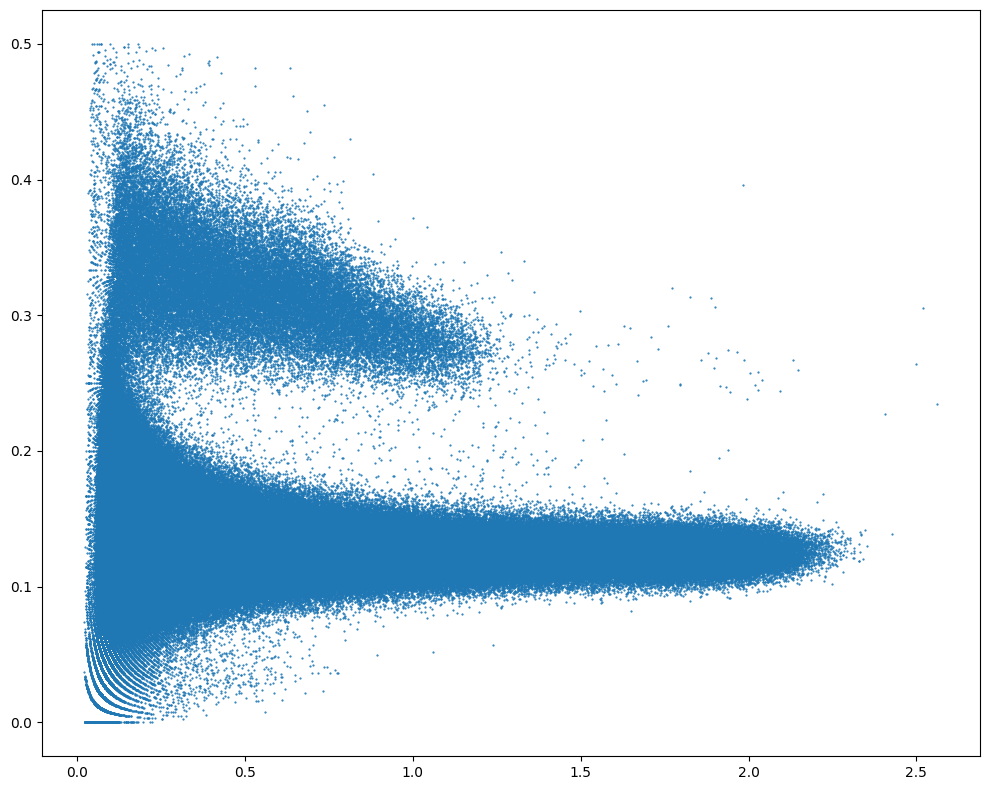

In [11]:
plot_scatter(psd_report["CALIB_ENERGY"], psd_report["tail / total"])

In [12]:
%%time
# Scan 2D histogram's energy slices and get bimodal fit

# Settings
start_scan_idx = 0
end_scan_idx = 420



end_scan_idx = min(end_scan_idx, len(Z))
psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)

df.head()

CPU times: total: 109 ms
Wall time: 1.21 s


,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.152368,0.010000,1.000000,0.354956,0.010000,0.000011,4.301570
1,1,0.158252,0.014342,1.000000,0.350000,0.040000,0.019296,1.498425
2,2,0.100000,0.100000,1.503290,0.356134,0.010000,0.064086,0.988818
3,3,0.100000,0.100000,1.404084,0.350000,0.040000,0.142625,0.758323
4,4,0.100000,0.100000,1.212370,0.360000,0.017846,0.486084,0.936920


In [13]:
# TODO get L0 from Californium source analysis
# for now, using value from "UBC Background 20221214-19 Update"
# TODO change this variable name to something more descriptive
L0 = 0.1966

## Classify Neutrons

In [14]:
# Define variable for all slice indexes to use
# (can be overridden if you only want to plot a subset of x axis)

all_slice_xs = xe[:end_scan_idx]

### Apply NASA Neutron Classification Window


This classification window is based on the technique outlined in _Fast Neutron Spectroscopy With Organic Scintillation Detectors in a High-Radiation Environment_, Baramsai _et al_.

We define the lower PSD bound as N standard deviations above the gamma mean. We find these points for each slice, then use smoothing and interpolation to generate a lower bound function.

The upper bound for the window is generated by adding a fixed offset to the lower bound value (found to be 0.2 based on observation of the paper's graphs).

As in all windows, the FOM cutoff is used as the left-most bound.

In [15]:
# Define lower and upper bounds (neutron_lb_fit, neutron_ub_fit)

window_offset = 0.2
sigma = 5

neutron_lb_fit, neutron_ub_fit = generate_nasa_neutron_window(df, 
                                                              all_slice_xs, 
                                                              window_offset=window_offset, 
                                                              sigma=sigma)

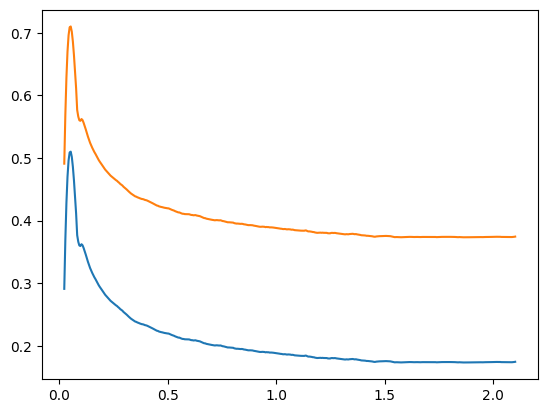

In [16]:
# Plot upper and lower bounds (diagnostic)

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [17]:
%%time
# Classify neutrons under NASA window
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, DataframeColumn.NEUTRON_CLASS, le_cutoff=L0)
# TODO save classification for later signal analysis

CPU times: total: 78.1 ms
Wall time: 82.1 ms


C:\Users\oliver.horner\Code\thunderbird_psd\active_notebooks\data_processing\processing\neutron_classification.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psd_report[label.value] = within_psd_bounds & within_eng_bounds


In [229]:
plot_start = datetime.now()

CPU times: total: 0 ns
Wall time: 0 ns


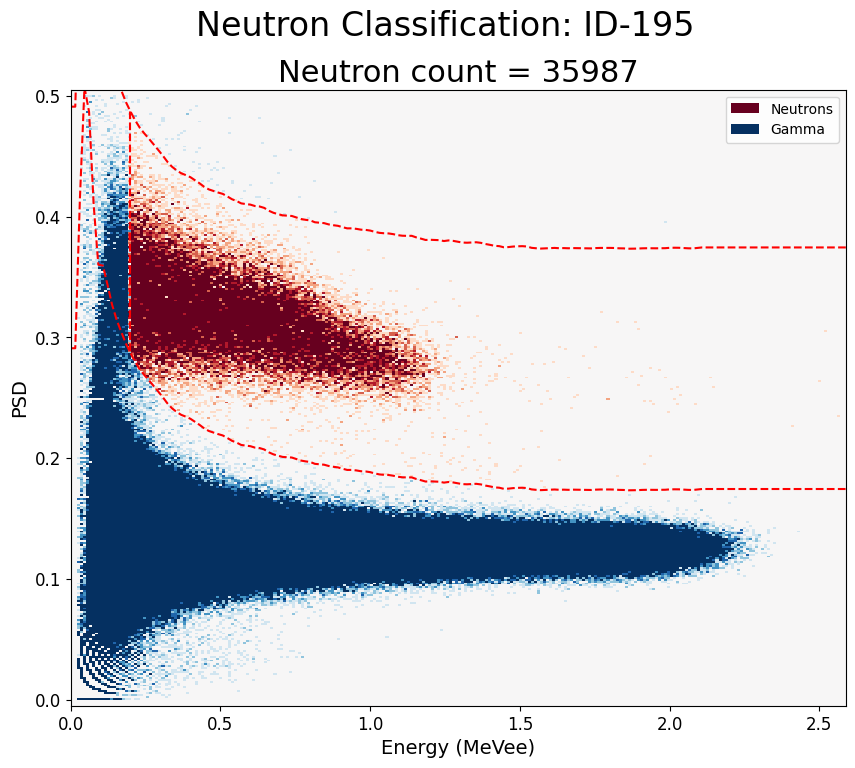

In [18]:
%time

fig, ax = plot_classification(psd_report, neutron_lb_fit, neutron_ub_fit, "ID-195")

#ax.set_xlabel("Time [s]")
#ax.set_ylabel("Neutron count rate [#/s]")
fig.savefig('ID-195_Classification.png')

In [19]:
plot_end = datetime.now()
plot_duration = plot_end - plot_start
print(f"Plot execution time: {plot_duration.total_seconds():.3f} s")

NameError: name 'plot_start' is not defined

In [20]:
neutron_report = psd_report[psd_report['NASA']]


## Device Period Classification

In [21]:
def timetag_generator(start_time: time) -> Callable[[time], int]:
    """Get a function that generates timetags from the start time.
    Timetags are measured in picoseconds from the starting time
    
    Parameters
    ----------
    start_time: time
        Starting time used by the produced timetag generator function.
        
    Returns
    -------
    fn: Callable[[time], int]
        A function that produces timetag for a given end time.
    """

    def get_timetag(end_time: time) -> int:
        """Generates timetag for a given end time.
        
        Parameters
        ----------
        end_time: time
            Time to be converted into a timetag
            
        Returns
        -------
        timestamp: int
            Timetag for the given time
        """
        end_datetime = datetime.combine(date.today(), end_time)
        start_datetime = datetime.combine(date.today(), start_time)
        total_seconds = end_datetime - start_datetime
        return int(total_seconds.total_seconds() * 1e12)
    
    return get_timetag


def offset_from_timestring(timestring: str) -> timedelta:
    """Converts an ISO format time string into a time duration
    
    Parameters
    ----------
    timestring: str
        ISO format time string to be converted
        
    Returns
    -------
    delta: timedelta
        Corresponding duration
    """
    hour_str, min_str, sec_str = timestring.split(":")
    return timedelta(
        hours=int(hour_str),
        minutes=int(min_str),
        seconds=int(sec_str)
    )

def offsets_from_timestrings(timestrings: list[str]) -> list[timedelta]:
    """Converts a list of ISO format time strings into a list of time durations
    
    Parameters
    ----------
    timestrings: list[str]
        List of timestrings to be converted
    
    Returns
    -------
    deltas: list[timedelta]
        List of corresponding durations
    """
    return [offset_from_timestring(timestring) for timestring in timestrings]

def time_difference(a: time, b: time) -> timedelta:
    """Find the difference between two times
    
    Parameters
    ----------
    a, b: time
        The given times
    
    Returns
    -------
    difference: timedelta
        The difference between the given times
    """
    dt_a = datetime.combine(date.today(), a)
    dt_b = datetime.combine(date.today(), b)
    return dt_a - dt_b

def get_period_bounds_timetags(
    detector_start: time,
    gas_analyzer_start: time,
    start_offsets: list[timedelta] | None = None,
    end_offsets: list[timedelta] | None = None,
    period_duration: timedelta | None = None
) -> list[tuple[int, int]]:
    """Find the timetags that bound a series of time periods based 
    on start and stop time offsets. 
    Timetags are used by the neutron detector, and are expressed in 
    picoseconds after the detector was started.
    Offsets are taken from the gas analyzer, and are therefore counted 
    from the start of that device.
    At least 2 of start_offsets, end_offsets and period_duration are used.
    If all 3 are present, start_offsets and end_offsets are used.
    
    Parameters
    ----------
    detector_start: time
        The start time of neutron detection on the CAEN software
    gas_analyzer_start: time
        The start time of the RGA gas analyser
    start_offsets: Optional[list[timedelta]], default None
        A list of time offsets representing the start of each period in
        the series
    end_offsets: Optional[list[timedelta]], default None
        A list of time offsets representing the end of each period in the 
        series
    period_duration: Optional[timedelta], default None
        The length of each period
    
    Returns
    -------
    bounds_timetags: list[tuple[int, int]]
        The start and end timetags for each period in the series
    """
    if period_duration is not None:
        if start_offsets is None and end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    else:
        if start_offsets is None or end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    
    if start_offsets is not None and end_offsets is not None and len(start_offsets) != len(end_offsets):
        raise ValueError(
            "Start and end offsets must have the same length"
        )
    
    gas_analyzer_start: datetime = datetime.combine(date.today(), 
                                                    gas_analyzer_start)
    
    if start_offsets is not None:
        start_times: list[datetime] = [gas_analyzer_start + delta
                                       for delta in start_offsets]
    if end_offsets is not None:
        end_times: list[datetime] = [gas_analyzer_start + delta
                                     for delta in end_offsets]
        
    if start_offsets is None:
        start_times = [end_time - period_duration 
                       for end_time in end_times]
    if end_offsets is None:
        end_times = [start_time + period_duration 
                     for start_time in start_times]
    
    start_times: list[time] = [dtime.time() for dtime in start_times]
    end_times: list[time] = [dtime.time() for dtime in end_times]
    
    get_timetag = timetag_generator(detector_start)
    
    start_timetags = [*map(get_timetag, start_times)]
    end_timetags = [*map(get_timetag, end_times)]
    timetags = list(zip(start_timetags, end_timetags))
    return timetags

def classify_period(
    dataframe: pd.DataFrame,
    column_name: str, 
    timetags: list[tuple[int, int]]
) -> pd.DataFrame:
    """Classifies events in a period of time, and in the overall period series.
    
    Classification is done by adding new columns to the given dataframe.
    All periods in the series are classified using the given name, and 
    individual periods are classified using the given name with an
    understore and the period index appended. (For example, if the 
    given column name was "PLASMA_ON", the periods would be classified 
    under "PLASMA_ON_0", "PLASMA_ON_1", and so on.)
    
    Parameters
    ----------
    dataframe: pd.DataFrame
        Dataframe with events to be classified
    column_name: str
        Base classification column name
    timetags: list[tuple[int, int]]
        List of bounds timetags for each period
    
    """
    # TODO change this to use category column and pd.cut()
    # Adds column to dataframe classifying events 
    # as happening in any of a series of time intervals
    # Get start/end timestamps from get_period_bounds_timestamps
    
    all_period_series = {i: dataframe['TIMETAG'].between(start, end)
                        for i, (start, end) in enumerate(timetags)}
    overall_series = pd.DataFrame(all_period_series).any(axis='columns')
    
    dataframe[column_name] = overall_series
    for i, period_series in all_period_series.items():
        dataframe[f"{column_name}_{i}"] = period_series
    return dataframe

In [234]:
%%time

all_offsets = [offsets_from_timestrings(timestrings) 
               if timestrings is not None
               else timestrings
               for timestrings 
               in [on_start_offsets, 
                   on_end_offsets, 
                   off_start_offsets, 
                   off_end_offsets]]
on_offsets = (all_offsets[0], all_offsets[1])
off_offsets = (all_offsets[2], all_offsets[3])
duration_delta = offset_from_timestring(duration) if duration is not None else duration

bounds_timetags = [
    get_period_bounds_timetags(
        caen_start_time, 
        rga_start_time, 
        start_offsets=start_offsets,
        end_offsets=end_offsets, 
        period_duration=duration_delta
    ) for start_offsets, end_offsets in (on_offsets, off_offsets)
]
on_bounds_timetags, off_bounds_timetags = bounds_timetags

psd_report = classify_period(
    psd_report, 
    on_name,
    timetags=on_bounds_timetags
)
psd_report = classify_period(
    psd_report,
    off_name,
    timetags=off_bounds_timetags
)

NameError: name 'on_start_offsets' is not defined

In [235]:
# Visualize time classification (optional, diagnostic)

# TODO simplify this into a timeline graph (how to do that?)
test = psd_report[psd_report[on_name]]
test2 = psd_report[psd_report[off_name]]
plt.scatter(test["TIMETAG"], test["tail / total"], s=0.5)
plt.scatter(test2["TIMETAG"], test2["tail / total"], s=0.5)
plt.ylabel("PSD")
plt.xlabel("Time (hours)")

NameError: name 'on_name' is not defined

## Fusion Analysis

### Setting up Trial data structure

In [23]:
# Function definition
# Experiment dataclass definition

def get_sigma_for_count(count: int) -> float:
    """Calculates estimated error for a given event count
    
    Parameters
    ----------
    count: int
        Event count
        
    Returns
    -------
    sigma: float
        Estimated error for the given event count
    """
    return np.sqrt(abs(count))

def get_sigma_for_count_delta(a:int, b:int) -> float:
    """Calculates estimated error for a difference between (or sum of) event counts
    
    Parameters
    ----------
    a, b: int
        Event counts
    
    Returns
    -------
    sigma: float
        Estimated error for the difference between (or sum of) the event counts
    """
    sigma_a = get_sigma_for_count(a)
    sigma_b = get_sigma_for_count(b)
    return np.sqrt(sigma_a**2 + sigma_b**2)

def counts_over_time_histogram(
    timetags: pd.Series, 
    dwell_time: int, 
    start_timetag: int,
    end_timetag: int
) -> tuple[np.ndarray, np.ndarray]:
    """Generates histogram of event counts per dwell time bin over a time period
    
    Parameters
    ----------
    timetags: pd.Series
        timetags (as picoseconds after neutron detector start) for all relevant events 
    dwell_time: int
        time period used for histogram bin width in seconds
    start_timetag: int
        starting timetag (as picoseconds after neutron detector start) for histogram period
    end_timetag: int
        ending timetag (as picoseconds after neutron detector start) for histogram period
    
        
    Returns
    -------
    counts: np.ndarray
        array of counts per bin
    bins: np.ndarray
        bin boundaries (as time in seconds)
    """
#     if total_time % dwell_time == 0:
#         total_time += 0.001
#     input_bins = np.arange(0, total_time, dwell_time)
    dwell_time = dwell_time * 1e12
    if (end_timetag - start_timetag) % dwell_time == 0:
        end_timetag += 1
    input_bins = np.arange(start_timetag, end_timetag, dwell_time)
    counts, bins = np.histogram(timetags, input_bins)
    return counts, bins

def make_report_line(
    message: str, value: int | float, error_value: float
):
    """Generates line for statistics report
    
    Parameters
    ----------
    message: str
        explanatory message portion of the report line
    value: int | float
        statistics value being reported
    error_value: float
        error in the value being reported
        
    Returns
    -------
    report_line: str
        the generated report line
    
    """
    return f"{message}: {value:.4f}, Error: {error_value:.4f}"

@dataclass
class Trial:
    """Class for storing trial data and calculating derived data.
    Each trial has a condition period, during which some experimental
    device was active (i.e. E-cell, plasma, etc.), and a background 
    period, during which the device was not active.
    To ensure correct results, the experimental state should be stable 
    before either period starts. For example, if some experimental parameter
    such as a chemical concentration takes time to increase when the device
    is active, the condition period should only start when that parameter
    reaches a steady value.
    To ensure correct event rate statistics, the condition and background 
    periods should have equal durations.
    
    Parameters
    ----------
    condition_dataframe: pd.DataFrame
        DataFrame containing only events in the condition period
    background_dataframe: pd.DataFrame
        DataFrame containing only events in the background period
    condition_time_bounds: tuple[int, int]
        The timetags that bound the condition period
    background_time_bounds: tuple[int, int]
        The timetags that bound the background period
    """
    condition_dataframe: pd.DataFrame
    background_dataframe: pd.DataFrame
    condition_time_bounds: tuple[int, int]
    background_time_bounds: tuple[int, int]
    
    EPSILON = 1e-6
    
    @property
    def condition_count(self) -> int:
        """The total event count in the condition period"""
        return self.condition_dataframe.shape[0]
    
    @property
    def background_count(self) -> int:
        """The total event count in the background period"""
        return self.background_dataframe.shape[0]
    
    @property
    def condition_time(self) -> float:
        """The total duration of the condition period"""
        start, end = self.condition_time_bounds
        return (end - start) * 1e-12
    
    @property
    def background_time(self) -> float:
        """The total duration of the background period"""
        start, end = self.background_time_bounds
        return (end - start) * 1e-12
    
    def count_delta(self):
        """The difference in total counts between condition and background periods"""
        return self.condition_count - self.background_count

    # Rate methods
    def condition_rate(self):
        """The overall average rate for the condition period"""
        return self.condition_count/self.condition_time
    
    def background_rate(self):
        """The overall average rate for the background period"""
        return self.background_count/self.background_time
    
    def rates(self):
        """Overall average rate for both periods"""
        return self.condition_rate(), self.background_rate()
    
    def rate_delta(self):
        """The difference in averages rates between condition and background periods"""
        return self.condition_rate() - self.background_rate()
    
    def rate_delta_is_valid(self):
        """Returns True if the condition and background periods have effectively equal durations.
        If this is true, we can consider the calculated rate difference to valid and useful.
        "Effectively equal" means the duration difference is below a small threshold.
        """
        delta_time = abs(self.condition_time - self.background_time)
        return delta_time < self.EPSILON
    
    # Error estimation methods
    def condition_sigma(self):
        """The estimated error in the condition periods' total event count"""
        return get_sigma_for_count(self.condition_count)
    
    def background_sigma(self):
        """The estimated error in the background periods' total event count"""
        return get_sigma_for_count(self.background_count)
    
    def count_sigmas(self):
        """Estimated error in total event count for both periods"""
        return self.condition_sigma(), self.background_sigma()
    
    def delta_sigma(self):
        """The estimated error in the event count difference"""
        return get_sigma_for_count_delta(self.condition_sigma(), 
                                         self.background_sigma())
    
    def condition_rate_sigma(self):
        """The estimated error in the condition period's average rate"""
        return self.condition_sigma()/self.condition_time
    
    def background_rate_sigma(self):
        """The estimated error in the background period's average rate"""
        return self.background_sigma()/self.background_time
    
    def rate_sigmas(self):
        ...  # STUB
    
    def rate_delta_sigma(self):
        """The estimated error in the average rate difference"""
        return get_sigma_for_count_delta(
            self.condition_rate_sigma(), 
            self.background_rate_sigma())

    # Statistical significance methods
    def is_rate_significantly_larger(self, sigmas: float) -> bool:
        cond_error_bounds = (self.condition_rate() - sigmas*self.condition_rate_sigma(), 
                             self.condition_rate() + sigmas*self.condition_rate_sigma())
        bg_error_bounds = (self.background_rate() - sigmas*self.background_rate_sigma(),
                           self.background_rate() + sigmas*self.background_rate_sigma())
        
        is_larger = self.condition_rate() > self.background_rate()
        # is_overlapping method from https://stackoverflow.com/a/12888920/1239124
        is_overlapping = (max(cond_error_bounds[0], bg_error_bounds[0]) <= 
                          min(cond_error_bounds[1], bg_error_bounds[1]))
        
        return is_larger and not is_overlapping
    
    # Rate histogram methods
    def condition_rate_time_series(
        self, dwell_time: int
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Determines the condition period's event rate over time as 
        a histogram.
        
        The condition period is divided into time "bins", and event rates 
        are calculated for each bin.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration. If the dwell time is such that the final
            bin would be smaller than the dwell time, it is not used.
            Therefore, each time bin always lasts the full dwell time.
            For example, for a period lasting 15 minutes, a dwell time of 
            6 minute would produce only 2 bins of 6 minutes long, with the
            remaining 3 minutes ignored.
            
        Returns
        -------
        rates: np.ndarray
            The event rates for each time bin
        errors: np.ndarray
            TODO complete this
        bins: np.ndarray
            The timetag boundaries for each time bin. Since the bins are
            contiguous, and adjacent bins share a boundary, the bins array
            is always one element longer than the rates array.
        """
        return self._rate_time_series(
            dwell_time,
            self.condition_dataframe,
            self.condition_time_bounds
        )
    
    def background_rate_time_series(
        self, dwell_time: int
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Determines the background period's event rate over time as 
        a histogram.
        
        The background period is divided into time "bins", and event rates 
        are calculated for each bin.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration. If the dwell time is such that the final
            bin would be smaller than the dwell time, it is not used.
            Therefore, each time bin always lasts the full dwell time.
            For example, for a period lasting 15 minutes, a dwell time of 
            6 minute would produce only 2 bins of 6 minutes long, with the
            remaining 3 minutes ignored.
            
        Returns
        -------
        rates: np.ndarray
            The event rates for each time bin
        bins: np.ndarray
            The timetag boundaries for each time bin. Since the bins are
            contiguous, and adjacent bins share a boundary, the bins array
            is always one element longer than the rates array.
        """
        return self._rate_time_series(
            dwell_time,
            self.background_dataframe,
            self.background_time_bounds
        )
    
    def both_rate_time_series(self, dwell_time: int):
        ...  # STUB
    
    def condition_rate_histogram(
        self, dwell_time: int, rate_bin_count: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the condition period's event rate distribution as 
        a histogram.
        
        The event rate histogram is calculated as in the 
        condition_rate_over_time() method. Then, rate bins are produced,
        and the number of rates falling in each bin are counted.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration for calculating event rates. 
            If the dwell time is such that the final bin would be smaller 
            than the dwell time, it is not used. Therefore, each time bin 
            always lasts the full dwell time. For example, for a period 
            lasting 15 minutes, a dwell time of 6 minute would produce 
            only 2 bins of 6 minutes long, with the remaining 3 minutes 
            ignored.
        rate_bin_count: int
            The number of rate bins to use
            
        Returns
        -------
        counts: np.ndarray
            The count for each event rate bin
        bins: np.ndarray
            The rate boundaries for each event rate bin. Since the bins 
            are contiguous, and adjacent bins share a boundary, the bins 
            array is always one element longer than the rates array.
        """
        rates, _, _ = self.condition_rate_time_series(dwell_time)
        return np.histogram(rates, rate_bin_count)
    
    def background_rate_histogram(
        self, dwell_time: int, rate_bin_count: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the background period's event rate distribution as 
        a histogram.
        
        The event rate histogram is calculated as in the 
        condition_rate_over_time() method. Then, rate bins are produced,
        and the number of rates falling in each bin are counted.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration for calculating event rates. 
            If the dwell time is such that the final bin would be smaller 
            than the dwell time, it is not used. Therefore, each time bin 
            always lasts the full dwell time. For example, for a period 
            lasting 15 minutes, a dwell time of 6 minute would produce 
            only 2 bins of 6 minutes long, with the remaining 3 minutes 
            ignored.
        rate_bin_count: int
            The number of rate bins to use
            
        Returns
        -------
        counts: np.ndarray
            The count for each event rate bin
        bins: np.ndarray
            The rate boundaries for each event rate bin. Since the bins 
            are contiguous, and adjacent bins share a boundary, the bins 
            array is always one element longer than the rates array.
        """
        rates, _, _ = self.background_rate_time_series(dwell_time)
        return np.histogram(rates, rate_bin_count)
    
    # Stat reporting methods
    def report_count_statistics(self) -> str:
        """Returns count statistics for this trial.
        This includes condition and background counts, count difference,
        and estimated error for each.
        """
        report_inputs = [
            ("Condition count", 
             self.condition_count, self.condition_sigma()),
            ("Background count", 
             self.background_count, self.background_sigma()),
            ("Count difference", 
             self.count_delta(), self.delta_sigma())
        ]
        reports = [make_report_line(*inputs) for inputs in report_inputs]
        return '\n'.join(reports)
    
    def report_rate_statistics(self) -> str:
        """Prints rate statistics for this trial.
        This includes condition and background rates, rate difference 
        (with validity), and estimated error for each.
        """
        report_inputs = [
            ("Condition rate (cps)", 
             self.condition_rate(), self.condition_rate_sigma()),
            ("Background rate (cps)", 
             self.background_rate(), self.background_rate_sigma()),
            ("Rate difference (cps)", 
             self.rate_delta(), self.rate_delta_sigma())
        ]
        reports = [make_report_line(*inputs) for inputs in report_inputs]
        validity = self.rate_delta_is_valid()
        reports.append(
            "Rate difference " +
            f"{self._is_or_is_not(validity)} valid " +
            f"(condition time {self.condition_time:.4f} s = " +
            f"background time {self.background_time:.4f} s)"
        )
        return '\n'.join(reports)
    
    def report_rate_significance(self, sigmas: float) -> str:
        significance = self.is_rate_significantly_larger(sigmas)
        return (f"Condition rate {self._is_or_is_not(significance)} " +
                f"significantly larger at {sigmas} sigmas")
    
    
    # Helpers
    def _rate_time_series(
        self, 
        dwell_time: int, 
        df: pd.DataFrame, 
        bounds: tuple[int, int]
    ) -> tuple[np.ndarray, np.ndarray]:
        counts, bins = counts_over_time_histogram(
            df['TIMETAG'],
            dwell_time,
            *bounds)
        rates = counts/dwell_time
        errors = np.sqrt(counts)/dwell_time
        return rates, errors, bins

    def _is_or_is_not(self, value: bool) -> str:
        return 'is' if value else 'is not'
        

def report_overall_count_statistics(trials: list[Trial]) -> str:
    """Reports overall count statistics for a list of trials."""
    total_cond_count = sum([trial.condition_count for trial in trials])
    total_bg_count = sum([trial.background_count for trial in trials])
    total_delta = total_cond_count - total_bg_count
    
    sigma_cond_count = get_sigma_for_count(total_cond_count)
    sigma_bg_count = get_sigma_for_count(total_bg_count)
    sigma_delta = get_sigma_for_count_delta(total_cond_count, total_bg_count)
    
    report_inputs = [
        ("Condition count", total_cond_count, sigma_cond_count),
        ("Background count", total_bg_count, sigma_bg_count),
        ("Count difference", total_delta, sigma_delta)
    ]
    reports = [make_report_line(*inputs) for inputs in report_inputs]
    return "\n".join(reports)

def report_average_rate_statistics(trials: list[Trial]):
    total_cond_count = sum([trial.condition_count for trial in trials])
    total_cond_time = sum([trial.condition_time for trial in trials])
    total_bg_count = sum([trial.background_count for trial in trials])
    total_bg_time = sum([trial.background_time for trial in trials])
    
    sigma_cond_count = get_sigma_for_count(total_cond_count)
    sigma_bg_count = get_sigma_for_count(total_bg_count)
    
    total_cond_rate = total_cond_count/total_cond_time
    total_bg_rate = total_bg_count/total_bg_time
    
    sigma_cond_rate = sigma_cond_count/total_cond_time
    sigma_bg_rate = sigma_bg_count/total_bg_time
    
    report_inputs = [
        ("Average condition rate (cps)", total_cond_rate, sigma_cond_rate),
        ("Average background rate (cps)", total_bg_rate, sigma_bg_rate)
    ]
    reports = [make_report_line(*inputs) for inputs in report_inputs]
    return "\n".join(reports)

In [24]:
neutron_report['TIMETAG']

15207      130574666357106
15244      131087726565409
15312      131716810204419
15419      132624834932663
15463      133012297577824
                ...       
882012    7315844096593778
882020    7315917862772687
882060    7316255834288704
882066    7316351716230577
882415    7319555624453032
Name: TIMETAG, Length: 35987, dtype: int64

In [25]:
dwell_time = 60

counts_over_time = counts_over_time_histogram(neutron_report["TIMETAG"], dwell_time, neutron_report['TIMETAG'].min(), neutron_report['TIMETAG'].max())
counts_over_time

(array([127, 152, 163, 178, 154, 184, 164, 190, 201, 193, 186, 206, 234,
        253, 261, 215, 245, 269, 218, 256, 232, 214, 240, 228, 218, 237,
        246, 248, 240, 216, 209, 239, 252, 253, 237, 264, 235, 270, 248,
        276, 281, 289, 292, 278, 313, 322, 299, 271, 330, 281, 310, 326,
        300, 301, 345, 320, 381, 370, 348, 325, 310, 380, 368, 346, 350,
        379, 317, 344, 314, 332, 373, 332, 305, 326, 348, 321, 344, 402,
        394, 395, 358, 361, 382, 331, 382, 375, 350, 370, 343, 371, 376,
        335, 319, 338, 374, 350, 347, 370, 334, 310, 345, 347, 362, 352,
        328, 350, 361, 291, 356, 348, 345, 356, 350, 314, 376, 310, 317,
        396, 342], dtype=int64),
 array([1.30574666e+14, 1.90574666e+14, 2.50574666e+14, 3.10574666e+14,
        3.70574666e+14, 4.30574666e+14, 4.90574666e+14, 5.50574666e+14,
        6.10574666e+14, 6.70574666e+14, 7.30574666e+14, 7.90574666e+14,
        8.50574666e+14, 9.10574666e+14, 9.70574666e+14, 1.03057467e+15,
        1.09057467e+15

In [26]:
dwell_time = 60

counts_over_time = counts_over_time_histogram(dp["Time"], dwell_time, neutron_report['TIMETAG'].min(), neutron_report['TIMETAG'].max())
counts_over_time

NameError: name 'dp' is not defined

In [27]:
dp["Time"]

NameError: name 'dp' is not defined

In [28]:
counts, bins = counts_over_time
zeroed_bins = (bins - bins[0])*1E-12
bin_widths = zeroed_bins[1:] - zeroed_bins[:-1]
rates = counts / bin_widths
rates

array([2.11666667, 2.53333333, 2.71666667, 2.96666667, 2.56666667,
       3.06666667, 2.73333333, 3.16666667, 3.35      , 3.21666667,
       3.1       , 3.43333333, 3.9       , 4.21666667, 4.35      ,
       3.58333333, 4.08333333, 4.48333333, 3.63333333, 4.26666667,
       3.86666667, 3.56666667, 4.        , 3.8       , 3.63333333,
       3.95      , 4.1       , 4.13333333, 4.        , 3.6       ,
       3.48333333, 3.98333333, 4.2       , 4.21666667, 3.95      ,
       4.4       , 3.91666667, 4.5       , 4.13333333, 4.6       ,
       4.68333333, 4.81666667, 4.86666667, 4.63333333, 5.21666667,
       5.36666667, 4.98333333, 4.51666667, 5.5       , 4.68333333,
       5.16666667, 5.43333333, 5.        , 5.01666667, 5.75      ,
       5.33333333, 6.35      , 6.16666667, 5.8       , 5.41666667,
       5.16666667, 6.33333333, 6.13333333, 5.76666667, 5.83333333,
       6.31666667, 5.28333333, 5.73333333, 5.23333333, 5.53333333,
       6.21666667, 5.53333333, 5.08333333, 5.43333333, 5.8    

In [242]:
on_len = len(on_start_offsets) if on_start_offsets is not None else len(on_end_offsets)
off_len = len(off_start_offsets) if off_start_offsets is not None else len(off_end_offsets)

on_query = [f"NASA & {on_name}_{i}" for i in range(on_len)]
off_query = [f"NASA & {off_name}_{i}" for i in range(off_len)]

on_df = [psd_report.query(query) for query in on_query]
off_df = [psd_report.query(query) for query in off_query]

trials_setup = list(zip(on_df, off_df, on_bounds_timetags, off_bounds_timetags))
trials = [Trial(*inputs) for inputs in trials_setup]

NameError: name 'on_start_offsets' is not defined

### Statistics

In [243]:
# Overall Statistics

overall_count_stats = report_overall_count_statistics(trials)
average_rate_stats = report_average_rate_statistics(trials)

NameError: name 'trials' is not defined

In [244]:
# Trial Statistics

def report_trial(trial_number, trial):
    reports = [
        f"Trial {trial_number}",
        "----------",
        trial.report_count_statistics(),
        "",
        trial.report_rate_statistics(),
        trial.report_rate_significance(1),
        "----------",
        ""
    ]
    return "\n".join(reports)

trial_reports = [report_trial(i+1, trial) 
                 for i, trial 
                 in enumerate(trials)]
trial_stats = "\n".join(trial_reports)

NameError: name 'trials' is not defined

In [245]:
report_lines = [
    f"Statistics Report: {experiment_display_name}",
    "",
    "Overall Count Statistics",
    "--------------------",
    overall_count_stats,
    "",
    "Average Rate Statistics",
    "--------------------",
    average_rate_stats,
    "",
    "Trial Statistics",
    "--------------------",
    trial_stats
]
final_report = "\n".join(report_lines)

with open(REPORT_ROOT / "stats_report.txt", "w") as reportfile:
    reportfile.write(final_report)
    
print(final_report)

NameError: name 'experiment_display_name' is not defined

### Count Rate Plot

In [29]:
# Define functions used in count rate plotting
def combine_period_histograms(
    counts: list[np.ndarray], 
    bins: list[np.ndarray]
) -> tuple[np.ndarray, np.ndarray]:
    """Combines period histograms together for proper plotting.
    Since periods are not adjacent, we must properly define the value
    of the intervening time as NaN, so it will not be plotted.
    
    Parameters
    ----------
    counts: list[np.ndarray]
        List of arrays holding bin counts for each period
    bins: list[np.ndarray]
        List of arrays holding bin boundaries for each period.
        Each bin array should be 1 element longer than the corresponding
        count array.
    
    Returns
    -------
    combined_counts: np.ndarray
        Array holding concatenated bin counts over all periods, with
        the time between periods having no count (NaN)
    combined_bins: np.ndarray
        Array holding concatenated bin boundaries over all periods
    """
    combined_bins = np.concatenate(bins, axis=None)
    
    sep = [np.nan] * len(counts)
    separated_counts = list(sum(zip(counts, sep), ())[:-1])
    combined_counts = np.concatenate(separated_counts, axis=None)
    
    return combined_counts, combined_bins


def plot_histogram(
    bins: list[np.ndarray], 
    counts: list[np.ndarray],
    labels: list[str],
    style: Literal['points', 'stairs'] = "points",
    errors: list[np.ndarray] | None = None,
    **kwargs
) -> tuple[plt.Figure, plt.Axes]:
    """Plot a set of histograms in one figure
    
    Parameters
    ----------
    bins: list[np.ndarray]
        list of histogram bins to use
    counts: list[np.ndarray]
        list of histogram counts to use
        Each list element must correspond to the element in the same position in `bins`
    labels: list[str]
        list of labels to use
        Each list element must correspond to the element in the same position in `bins`
    style: Literal['points', 'stairs'], default "points"
        plotting style
        The 'points' option creates a scatterplot, while 'stairs' creates a stair plot.
    kwargs
        Other formatting options used in the Matplotlib Axes.plot() or Axes.stairs() functions (as appropriate)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for histogram plot
    ax: plt.Axes
        plot axes for histogram plot
    """
    if errors is None:
        errors = [None for x in bins]
    
    fig, ax = plt.subplots(dpi=140)
    
    for bin, count, error, label in zip(bins, counts, errors, labels):
        if style == "points":
            ax.errorbar(bin[:-1], count, fmt="o", 
                        label=label, yerr=error, **kwargs)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4, **kwargs)
    
    ax.legend()
    return fig, ax

In [30]:
"""
# Create the initial histogram plot
fig, ax = plot_histogram([zeroed_bins], [rates], '')


# Set the x-axis limits in seconds
ax.set_xlim(210, 3600)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax.set_xlim(xmin_min, xmax_min)

ax.set_xlim(5, 65)

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts: 0-30 minutes and 30-60 minutes
split_point = int(len(rates) / 2)
rates_part1 = rates[:split_point]
rates_part2 = rates[split_point:]
new_zeroed_bins_part1 = new_zeroed_bins[:split_point]
new_zeroed_bins_part2 = new_zeroed_bins[split_point:]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the first 30 minutes in blue as dots
ax.scatter(new_zeroed_bins_part1, rates_part1, color='blue', s=dot_size, label='15 keV')

# Plot the next 30 minutes in orange as dots
ax.scatter(new_zeroed_bins_part2, rates_part2, color='orange', s=dot_size, label='0 keV')

# Add a vertical dashed line at the split point (30 minutes)
ax.axvline(x=33, color='lightgray', linestyle='-', linewidth=1)

ax.set_xlabel("Time [minutes]")  # Update x-axis label

ax.set_ylabel("Neutron count rate [#/s]")



# Add a legend for the plot
ax.legend(loc='upper right')

# Add a title above the plot
fig.text(0.5, 0.90, "Copper disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Copper_disk.png')

# Show the plot (optional)
plt.show()
"""

'\n# Create the initial histogram plot\nfig, ax = plot_histogram([zeroed_bins], [rates], \'\')\n\n\n# Set the x-axis limits in seconds\nax.set_xlim(210, 3600)\n\n# Convert the x-axis limits to minutes\nxmin_sec, xmax_sec = ax.get_xlim()\nxmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60\nax.set_xlim(xmin_min, xmax_min)\n\nax.set_xlim(5, 65)\n\n# Ensure both zeroed_bins and rates have the same length\nnum_points = len(zeroed_bins)\n\n# If rates have one extra point, remove the last point\nif len(rates) > num_points:\n    rates = rates[:-1]\n\n# Resample zeroed_bins to match the length of rates\nnew_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)\n\n# Divide the data into two parts: 0-30 minutes and 30-60 minutes\nsplit_point = int(len(rates) / 2)\nrates_part1 = rates[:split_point]\nrates_part2 = rates[split_point:]\nnew_zeroed_bins_part1 = new_zeroed_bins[:split_point]\nnew_zeroed_bins_part2 = new_zeroed_bins[split_point:]\n\n# Set the dot size (increase as nee

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


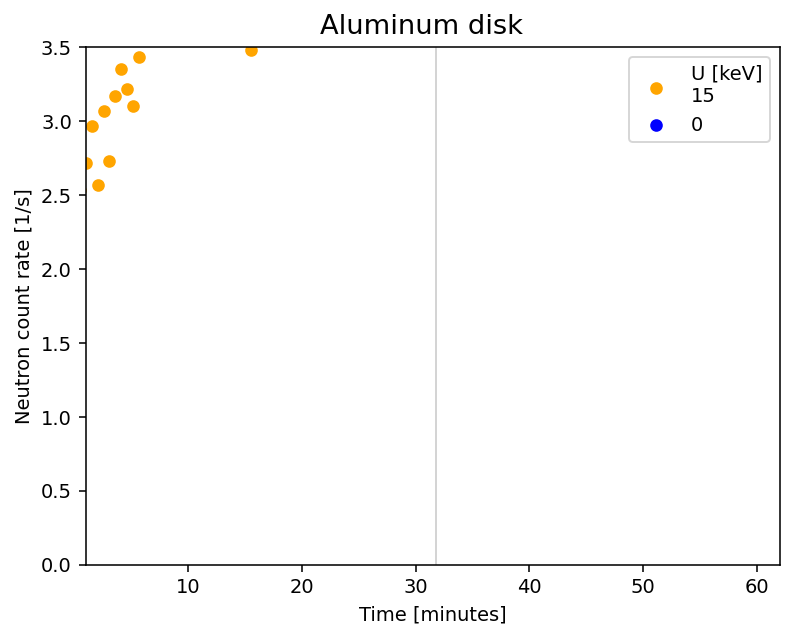

In [31]:
# Aluminum only neutrons
fig, ax = plot_histogram([zeroed_bins], [rates], '')

# Set the x-axis limits in seconds
ax.set_xlim(0, 3689.334)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax.set_xlim(xmin_min, xmax_min)

ax.set_xlim(1, 62)

# Set the y-axis limits
ax.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 30

# Plot the data points with y-values above 0.5 in orange
line1 = ax.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size)

# Plot the data points with y-values below or equal to 0.5 in blue
line2 = ax.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size)

# Add a vertical dashed line at the split point (30 minutes)
ax.axvline(x=31.8, color='lightgray', linestyle='-', linewidth=1)

# Combine the legend handles and labels from all axes
lines = [line1, line2]
labels = ['U [keV]\n15','0']

# Show the legend
plt.legend(lines, labels, loc='upper right')

ax.set_xlabel("Time [minutes]")  # Update x-axis label
ax.set_ylabel("Neutron count rate [1/s]")

# Add a title above the plot
fig.text(0.5, 0.90, "Aluminum disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Aluminum_disk.png')

# Show the plot (optional)
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


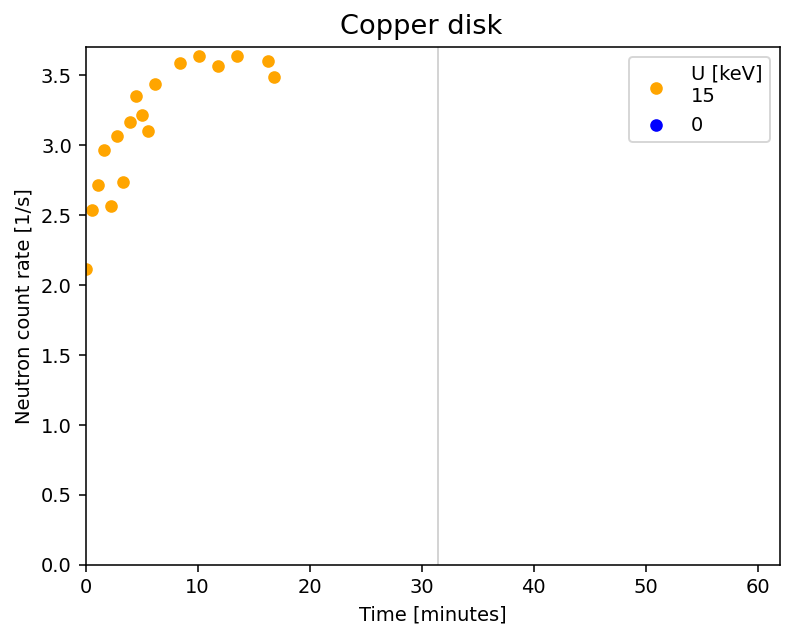

In [32]:
# copper only neutrons
fig, ax = plot_histogram([zeroed_bins], [rates], '')

# Set the x-axis limits in seconds
ax.set_xlim(0, 4012.630)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax.set_xlim(xmin_min, xmax_min)

ax.set_xlim(0, 62)

# Set the y-axis limits
ax.set_ylim(0, 3.7)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 30

# Plot the data points with y-values above 0.5 in orange
line1 = ax.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size)

# Plot the data points with y-values below or equal to 0.5 in blue
line2 = ax.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size)

# Add a vertical dashed line at the split point (30 minutes)
ax.axvline(x=31.5, color='lightgray', linestyle='-', linewidth=1)

# Combine the legend handles and labels from all axes
lines = [line1, line2]
labels = ['U [keV]\n15','0']

# Show the legend
plt.legend(lines, labels, loc='upper right')

ax.set_xlabel("Time [minutes]")  # Update x-axis label
ax.set_ylabel("Neutron count rate [1/s]")

# Add a title above the plot
fig.text(0.5, 0.90, "Copper disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Copper_disk.png')

# Show the plot (optional)
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


NameError: name 'dp' is not defined

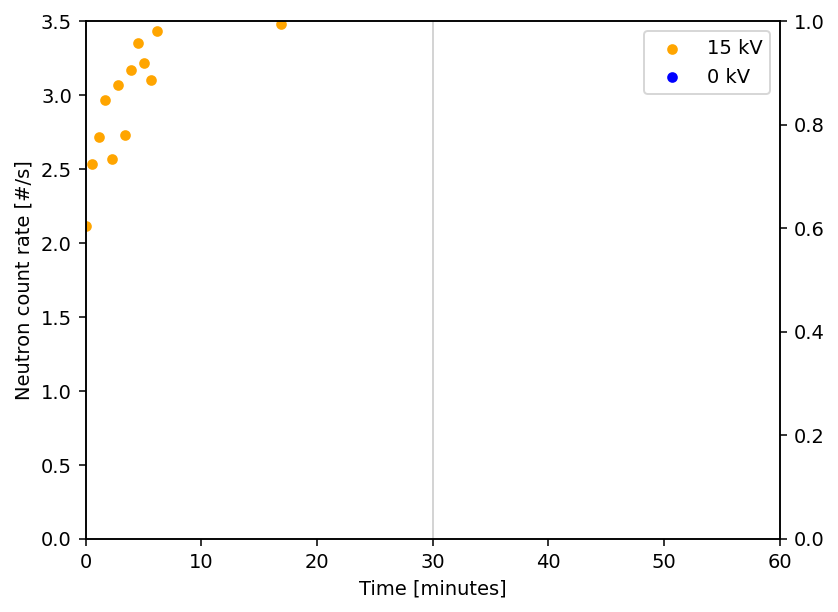

In [33]:
import math

# Create the initial histogram plot
fig, ax1 = plot_histogram([zeroed_bins], [rates], '')

# Set the x-axis limits in seconds
ax1.set_xlim(0, 4012.630)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(0, 60)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the data points with y-values above 0.5 in orange
ax1.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size, label='15 kV')

# Plot the data points with y-values below or equal to 0.5 in blue
ax1.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size, label='0 kV')

# Add a vertical dashed line at the split point (30 minutes)
ax1.axvline(x=30, color='lightgray', linestyle='-', linewidth=1)

ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [#/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')

# Create a second y-axis
ax2 = ax1.twinx()



# Plot the second data series on the second y-axis
ax2.plot(dp.index/60, dp.iloc[:, 3], color='red', label='Aluminum disk - P')  # Assuming the second column is used



# Set labels for the y-axis of the second plot
ax2.set_ylabel("Pressure [Torr]")
ax2.set_ylim(0.00012, 0.00015)
#ax2.set_yscale('log')



# Add a legend for both plots
legend1 = ax1.legend(loc='center left')
legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.64, 0.87))
legend2.set_bbox_to_anchor((0.99, 1))

# Add a title above the plot
fig.text(0.5, 0.90, "Aluminum disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Aluminum_disk.png')

# Show the plot (optional)
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


NameError: name 'dp' is not defined

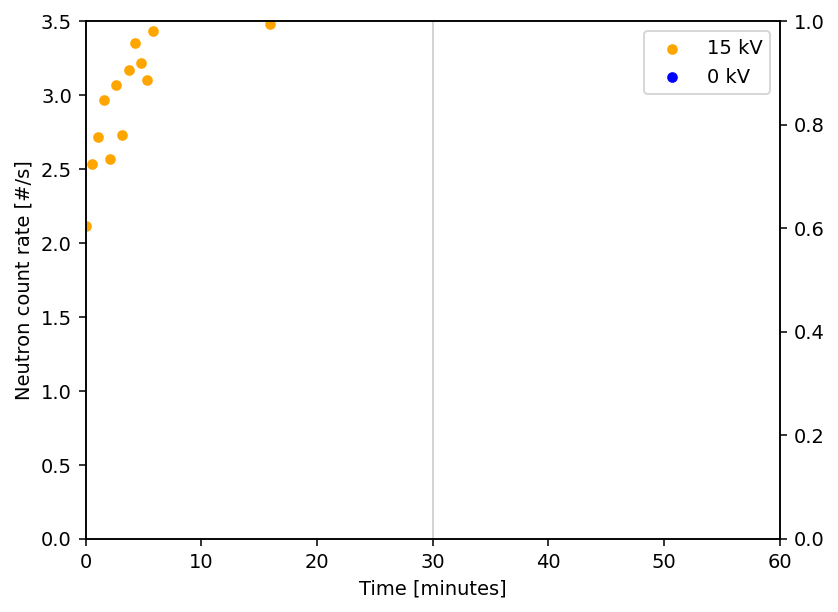

In [34]:
# Create the initial histogram plot
fig, ax1 = plot_histogram([zeroed_bins], [rates], '')

# Set the x-axis limits in seconds
ax1.set_xlim(0, 3800)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(0, 60)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the data points with y-values above 0.5 in orange
ax1.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size, label='15 kV')

# Plot the data points with y-values below or equal to 0.5 in blue
ax1.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size, label='0 kV')

# Add a vertical dashed line at the split point (30 minutes)
ax1.axvline(x=30, color='lightgray', linestyle='-', linewidth=1)

ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [#/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')

# Create a second y-axis
ax2 = ax1.twinx()


# dp['smoothed_pressure'] contains pressure values in Torr
pressure_values = dp['smoothed_pressure']

# Define the mantissa and exponent for pressure
mantissa = pressure_values * 1e-4  # Convert to mantissa (divide by 1e5)
exponent = -4  # Define the exponent

# Plot the second data series on the second y-axis
ax2.plot(dp.index/60, mantissa, color='red', label='Aluminum disk - P')  # Assuming the second column is used



# Set labels for the y-axis of the second plot
ax2.set_ylabel("Pressure [Torr]")
ax2.set_ylim(0.00012, 0.00015)



# Add a legend for both plots
legend1 = ax1.legend(loc='center left')
legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.64, 0.87))
legend2.set_bbox_to_anchor((0.99, 1))

# Add a title above the plot
fig.text(0.5, 0.90, "Aluminum disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Aluminum_disk.png')

# Show the plot (optional)
plt.show()




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


NameError: name 'dp' is not defined

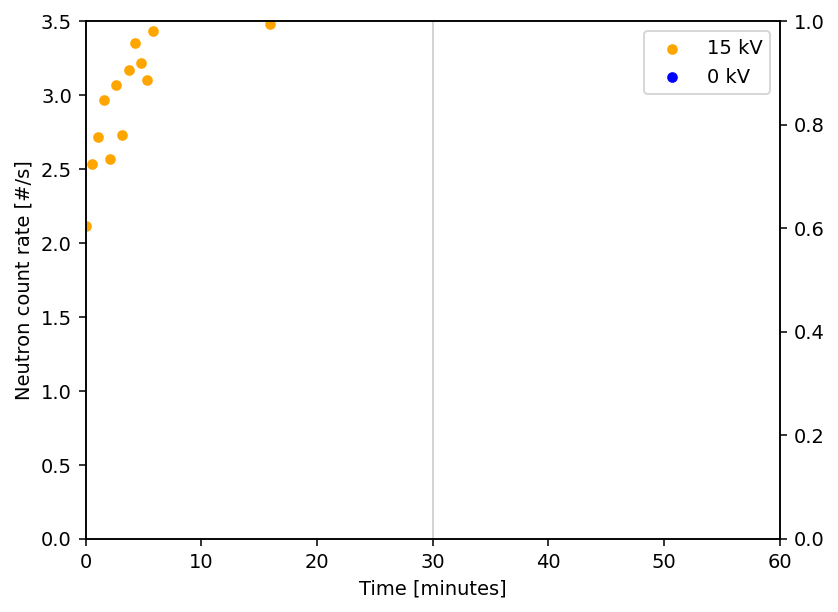

In [35]:

# Create the initial histogram plot
fig, ax1 = plot_histogram([zeroed_bins], [rates], '')

# Set the x-axis limits in seconds
ax1.set_xlim(0, 3800)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(0, 60)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the data points with y-values above 0.5 in orange
ax1.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size, label='15 kV')

# Plot the data points with y-values below or equal to 0.5 in blue
ax1.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size, label='0 kV')

# Add a vertical dashed line at the split point (30 minutes)
ax1.axvline(x=30, color='lightgray', linestyle='-', linewidth=1)

ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [#/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')

# Create a second y-axis
ax2 = ax1.twinx()



# Plot the second data series on the second y-axis
ax2.plot(dp.index/60, dp.iloc[:, 3], color='red', label='Aluminum disk - P')  # Assuming the second column is used



# Set labels for the y-axis of the second plot
ax2.set_ylabel("Pressure [Torr]")
ax2.set_ylim(0.00012, 0.00015)




# Add a legend for both plots
legend1 = ax1.legend(loc='center left')
legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.64, 0.87))
legend2.set_bbox_to_anchor((0.99, 1))

# Add a title above the plot
fig.text(0.5, 0.90, "Aluminum disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Aluminum_disk.png')

# Show the plot (optional)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the initial histogram plot
fig, ax1 = plt.subplots()

# Set the x-axis limits in seconds
ax1.set_xlim(210, 3600)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(4, 56)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the data points with y-values above 0.5 in orange
ax1.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size, label='15 kV')

# Plot the data points with y-values below or equal to 0.5 in blue
ax1.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size, label='0 kV')

# Add a vertical dashed line at the split point (30 minutes)
ax1.axvline(x=30, color='lightgray', linestyle='-', linewidth=1)

ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [#/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot the second data series on the second y-axis
ax2.plot(dp.index/60, dp.iloc[:, 3] * 1e4, color='red', label='Pressure')  # Adjusted the y-values

# Set labels for the y-axis of the second plot with "x 10^4" added
ax2.set_ylabel("Pressure [Torr] x $10^-4$")
ax2.set_ylim(0.00012 * 1e4, 0.00015 * 1e4)  # Adjusted the y-axis limits

# Add a legend for both plots
legend1 = ax1.legend(loc='center left')
legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.744, 0.84))
legend2.set_bbox_to_anchor((0.99, 1))

# Add a title above the plot
fig.text(0.5, 0.90, "Cupper disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Cupper_disk_NP.png')

# Show the plot (optional)
plt.show()


NameError: name 'di' is not defined

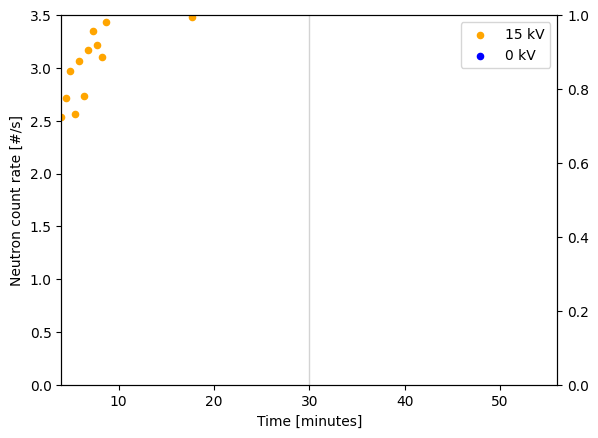

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Create the initial histogram plot
fig, ax1 = plt.subplots()

# Set the x-axis limits in seconds
ax1.set_xlim(210, 3600)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(4, 56)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the data points with y-values above 0.5 in orange
ax1.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size, label='15 kV')

# Plot the data points with y-values below or equal to 0.5 in blue
ax1.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size, label='0 kV')

# Add a vertical dashed line at the split point (30 minutes)
ax1.axvline(x=30, color='lightgray', linestyle='-', linewidth=1)

ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [#/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')

# Create a second y-axis
ax2 = ax1.twinx()


# Plot the second data series on the second y-axis
ax2.plot(di.index/60, di.iloc[:, 3], color='red', label='Current')  # Adjusted the y-values

# Set labels for the y-axis of the second plot with "x 10^4" added
ax2.set_ylabel("Current [mA]")
ax2.set_ylim(0, 0.5)  # Adjusted the y-axis limits




# Add a legend for both plots
legend1 = ax1.legend(loc='center left')
legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.744, 0.84))
legend2.set_bbox_to_anchor((0.98, 1))

# Add a title above the plot
fig.text(0.5, 0.90, "Cupper disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Cupper_disk_NI.png')

# Show the plot (optional)
plt.show()


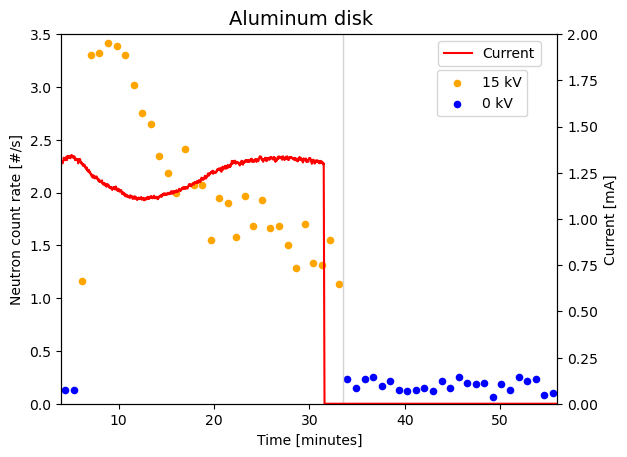

In [196]:
import matplotlib.pyplot as plt
import numpy as np

# Create the initial histogram plot
fig, ax1 = plt.subplots()

# Set the x-axis limits in seconds
ax1.set_xlim(210, 3600)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(4, 56)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the data points with y-values above 0.5 in orange
ax1.scatter(new_zeroed_bins_part1, rates_part1, color='orange', s=dot_size, label='15 kV')

# Plot the data points with y-values below or equal to 0.5 in blue
ax1.scatter(new_zeroed_bins_part2, rates_part2, color='blue', s=dot_size, label='0 kV')

# Add a vertical dashed line at the split point (30 minutes)
ax1.axvline(x=33.5, color='lightgray', linestyle='-', linewidth=1)

ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [#/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')

# Create a second y-axis
ax2 = ax1.twinx()


# Plot the second data series on the second y-axis
ax2.plot(di.index/60, di.iloc[:, 3], color='red', label='Current')  # Adjusted the y-values

# Set labels for the y-axis of the second plot with "x 10^4" added
ax2.set_ylabel("Current [mA]")
ax2.set_ylim(0, 2)  # Adjusted the y-axis limits




# Add a legend for both plots
legend1 = ax1.legend(loc='center left')
legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.744, 0.84))
legend2.set_bbox_to_anchor((0.98, 1))

# Add a title above the plot
fig.text(0.5, 0.90, "Aluminum disk", ha='center', fontsize=14)

# Save the plot
fig.savefig('Aluminum_disk_NI.png')

# Show the plot (optional)
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


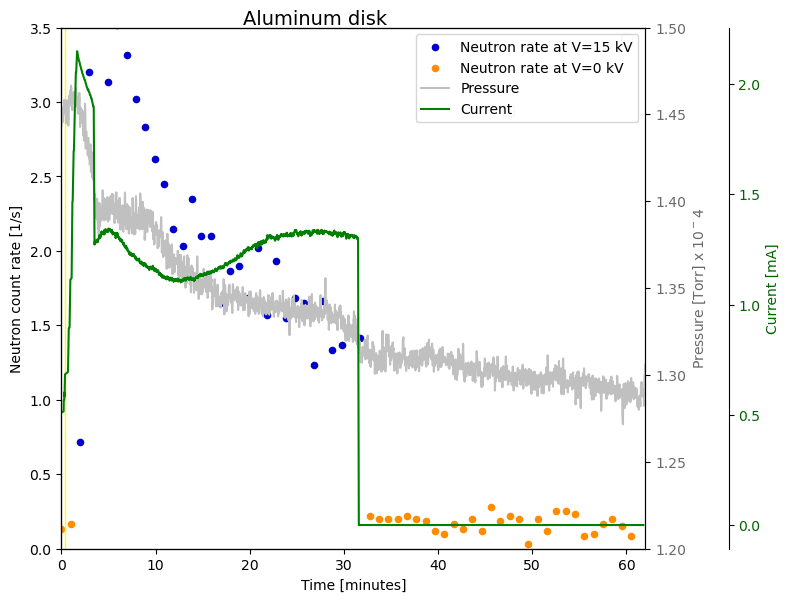

In [130]:
#Aluminum


fig, ax1 = plt.subplots(figsize=(8, 6))

# Set the x-axis limits in seconds
ax1.set_xlim(0, 3689.334)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(0, 62)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
rates_part1 = [rate for rate in rates if rate > 0.5]
new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

rates_part2 = [rate for rate in rates if rate <= 0.5]
new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 20

# Plot the data points with y-values above 0.5 in orange
line1 = ax1.scatter(new_zeroed_bins_part1, rates_part1, color='mediumblue', s=dot_size)

# Plot the data points with y-values below or equal to 0.5 in blue
line2 = ax1.scatter(new_zeroed_bins_part2, rates_part2, color='darkorange', s=dot_size)

# Add a vertical dashed line at the split point (30 minutes)
#ax1.axvline(x=33.5, color='yellow', linestyle='-', linewidth=1)
ax1.axvline(x=0.4, color='yellow', linestyle='-', linewidth=1)

ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [1/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot the second data series on the second y-axis
line3 = ax2.plot(dp.index/60, dp.iloc[:, 3] * 1e4, color='silver')  # Adjusted the y-values

# Set labels for the y-axis of the second plot with "x 10^4" added
ax2.set_ylabel("Pressure [Torr] x $10^-4$", color='dimgray')
ax2.set_ylim(0.00012 * 1e4, 0.00015 * 1e4)  # Adjusted the y-axis limits
ax2.tick_params(axis='y', labelcolor='dimgray')
# Add a legend for both plots
legend1 = ax1.legend(loc='center left')
legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.744, 0.84))
legend2.set_bbox_to_anchor((0.99, 1))

# Add a title above the plot
fig.text(0.4, 0.971, "Aluminum disk", ha='center', fontsize=14)


ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Adjust the position
ax3.set_ylabel('Current [mA]', color='darkgreen')
# Plot the second data series on the second y-axis
line4 = ax3.plot(di.index/60, di.iloc[:, 3], color='green')  # Adjusted the y-values

ax3.tick_params(axis='y', labelcolor='darkgreen')

# Combine the legend handles and labels from all axes
lines = [line1, line2, line3[0], line4[0]]
labels = ['Neutron rate at V=15 kV', 'Neutron rate at V=0 kV', 'Pressure', 'Current']

# Show the legend
plt.legend(lines, labels, loc='upper right')


# Show the legend
plt.legend(lines, labels, loc='upper right')



# Adjust the overall layout
fig.tight_layout()

fig.savefig('NIP-Al.png')


# Show the plot
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


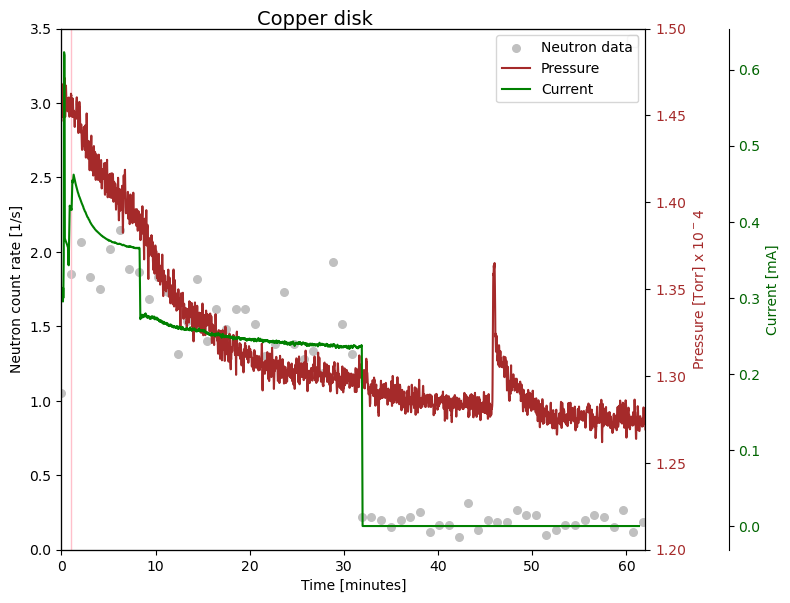

In [210]:
#Cupper


fig, ax1 = plt.subplots(figsize=(8, 6))

# Set the x-axis limits in seconds
ax1.set_xlim(0, 4012.630)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(0, 62)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
#rates_part1 = [rate for rate in rates if rate > 0.5]
#new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

#rates_part2 = [rate for rate in rates if rate <= 0.5]
#new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 30

# Plot the data points with y-values above 0.5 in orange
#line1 = ax1.scatter(new_zeroed_bins_part1, rates_part1, color='mediumblue', s=dot_size)
line1 = ax1.scatter(new_zeroed_bins, rates, color='silver', s=dot_size)


# Plot the data points with y-values below or equal to 0.5 in blue
#line2 = ax1.scatter(new_zeroed_bins_part2, rates_part2, color='darkorange', s=dot_size)

# Add a vertical dashed line at the split point (30 minutes)
#ax1.axvline(x=32, color='yellow', linestyle='-', linewidth=1)
ax1.axvline(x=1, color='pink', linestyle='-', linewidth=1)


ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [1/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot the second data series on the second y-axis
line3 = ax2.plot(dp.index/60, dp.iloc[:, 3] * 1e4, color='brown')  # Adjusted the y-values

# Set labels for the y-axis of the second plot with "x 10^4" added
ax2.set_ylabel("Pressure [Torr] x $10^-4$", color='brown')
ax2.set_ylim(0.00012 * 1e4, 0.00015 * 1e4)  # Adjusted the y-axis limits
ax2.tick_params(axis='y', labelcolor='brown')
# Add a legend for both plots
#legend1 = ax1.legend(loc='center left')
#legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.744, 0.84))
legend2.set_bbox_to_anchor((0.99, 1))

# Add a title above the plot
fig.text(0.4, 0.972, "Copper disk", ha='center', fontsize=14)


ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Adjust the position
ax3.set_ylabel('Current [mA]', color='darkgreen')
# Plot the second data series on the second y-axis
line4 = ax3.plot(di.index/60, di.iloc[:, 3], color='green')  # Adjusted the y-values

ax3.tick_params(axis='y', labelcolor='darkgreen')

# Combine the legend handles and labels from all axes
lines = [line1, line3[0], line4[0]]
labels = ['Neutron data', 'Pressure', 'Current']

# Show the legend
plt.legend(lines, labels, loc='upper right')


# Show the legend
#plt.legend(lines, labels, loc='upper right')



# Adjust the overall layout
fig.tight_layout()

fig.savefig('NIP-Cu.png')


# Show the plot
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


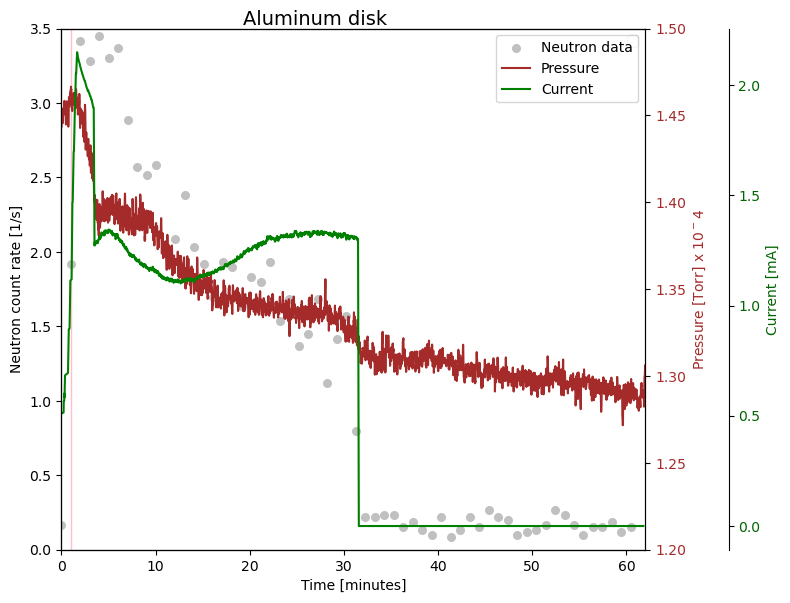

In [257]:
#Aluminum


fig, ax1 = plt.subplots(figsize=(8, 6))

# Set the x-axis limits in seconds
ax1.set_xlim(0, 3689.334)

# Convert the x-axis limits to minutes
xmin_sec, xmax_sec = ax1.get_xlim()
xmin_min, xmax_min = xmin_sec / 60, xmax_sec / 60
ax1.set_xlim(xmin_min, xmax_min)

ax1.set_xlim(0, 62)

# Set the y-axis limits
ax1.set_ylim(0, 3.5)  # Assuming the y-values range from 0 to 1

# Ensure both zeroed_bins and rates have the same length
num_points = len(zeroed_bins)

# If rates have one extra point, remove the last point
if len(rates) > num_points:
    rates = rates[:-1]

# Resample zeroed_bins to match the length of rates
new_zeroed_bins = np.linspace(xmin_min, xmax_min, len(rates), endpoint=False)

# Divide the data into two parts based on the y-value (above or below 0.5)
#rates_part1 = [rate for rate in rates if rate > 0.5]
#new_zeroed_bins_part1 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] > 0.5]

#rates_part2 = [rate for rate in rates if rate <= 0.5]
#new_zeroed_bins_part2 = [new_zeroed_bins[i] for i in range(len(rates)) if rates[i] <= 0.5]

# Set the dot size (increase as needed)
dot_size = 30

# Plot the data points with y-values above 0.5 in orange
#line1 = ax1.scatter(new_zeroed_bins_part1, rates_part1, color='mediumblue', s=dot_size)
line1 = ax1.scatter(new_zeroed_bins, rates, color='silver', s=dot_size)


# Plot the data points with y-values below or equal to 0.5 in blue
#line2 = ax1.scatter(new_zeroed_bins_part2, rates_part2, color='darkorange', s=dot_size)

# Add a vertical dashed line at the split point (30 minutes)
#ax1.axvline(x=32, color='yellow', linestyle='-', linewidth=1)
ax1.axvline(x=1, color='pink', linestyle='-', linewidth=1)


ax1.set_xlabel("Time [minutes]")  # Update x-axis label
ax1.set_ylabel("Neutron count rate [1/s]")

# Add a legend for the plot
ax1.legend(loc='upper right')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot the second data series on the second y-axis
line3 = ax2.plot(dp.index/60, dp.iloc[:, 3] * 1e4, color='brown')  # Adjusted the y-values

# Set labels for the y-axis of the second plot with "x 10^4" added
ax2.set_ylabel("Pressure [Torr] x $10^-4$", color='brown')
ax2.set_ylim(0.00012 * 1e4, 0.00015 * 1e4)  # Adjusted the y-axis limits
ax2.tick_params(axis='y', labelcolor='brown')
# Add a legend for both plots
#legend1 = ax1.legend(loc='center left')
#legend2 = ax2.legend(loc='upper right')

legend1.set_bbox_to_anchor((0.744, 0.84))
legend2.set_bbox_to_anchor((0.99, 1))

# Add a title above the plot
fig.text(0.4, 0.972, "Aluminum disk", ha='center', fontsize=14)


ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Adjust the position
ax3.set_ylabel('Current [mA]', color='darkgreen')
# Plot the second data series on the second y-axis
line4 = ax3.plot(di.index/60, di.iloc[:, 3], color='green')  # Adjusted the y-values

ax3.tick_params(axis='y', labelcolor='darkgreen')

# Combine the legend handles and labels from all axes
lines = [line1, line3[0], line4[0]]
labels = ['Neutron data', 'Pressure', 'Current']

# Show the legend
plt.legend(lines, labels, loc='upper right')


# Show the legend
#plt.legend(lines, labels, loc='upper right')



# Adjust the overall layout
fig.tight_layout()

fig.savefig('NIP-Al.png')


# Show the plot
plt.show()



In [199]:
bins_seconds = bins*1e-12
bins_seconds

array([2.15595341e-01, 6.02155953e+01, 1.20215595e+02, 1.80215595e+02,
       2.40215595e+02, 3.00215595e+02, 3.60215595e+02, 4.20215595e+02,
       4.80215595e+02, 5.40215595e+02, 6.00215595e+02, 6.60215595e+02,
       7.20215595e+02, 7.80215595e+02, 8.40215595e+02, 9.00215595e+02,
       9.60215595e+02, 1.02021560e+03, 1.08021560e+03, 1.14021560e+03,
       1.20021560e+03, 1.26021560e+03, 1.32021560e+03, 1.38021560e+03,
       1.44021560e+03, 1.50021560e+03, 1.56021560e+03, 1.62021560e+03,
       1.68021560e+03, 1.74021560e+03, 1.80021560e+03, 1.86021560e+03,
       1.92021560e+03, 1.98021560e+03, 2.04021560e+03, 2.10021560e+03,
       2.16021560e+03, 2.22021560e+03, 2.28021560e+03, 2.34021560e+03,
       2.40021560e+03, 2.46021560e+03, 2.52021560e+03, 2.58021560e+03,
       2.64021560e+03, 2.70021560e+03, 2.76021560e+03, 2.82021560e+03,
       2.88021560e+03, 2.94021560e+03, 3.00021560e+03, 3.06021560e+03,
       3.12021560e+03, 3.18021560e+03, 3.24021560e+03, 3.30021560e+03,
      

In [200]:
caen_start_time = datetime.fromisoformat("2023-09-01 10:22:52.373000-07:00")

In [55]:
di["Time_dt"] = pd.to_datetime(di["Time"]).dt.tz_localize("America/Vancouver")
di

,Time,Volatge(V),Current(mA),smoothed_current,Time_dt
5,31-Aug-23-13:19:38,2001,0.513,0.51300,2023-08-31 13:19:38-07:00
6,31-Aug-23-13:19:39,1852,0.513,0.51300,2023-08-31 13:19:39-07:00
7,31-Aug-23-13:19:40,2001,0.513,0.51300,2023-08-31 13:19:40-07:00
8,31-Aug-23-13:19:41,2001,0.514,0.51325,2023-08-31 13:19:41-07:00
9,31-Aug-23-13:19:42,2001,0.514,0.51340,2023-08-31 13:19:42-07:00
...,...,...,...,...,...
3695,31-Aug-23-14:21:09,0,0.000,0.00000,2023-08-31 14:21:09-07:00
3696,31-Aug-23-14:21:10,0,0.000,0.00000,2023-08-31 14:21:10-07:00
3697,31-Aug-23-14:21:11,0,0.000,0.00000,2023-08-31 14:21:11-07:00
3698,31-Aug-23-14:21:12,0,0.000,0.00000,2023-08-31 14:21:12-07:00


In [56]:
dp["Time_dt"] = pd.to_datetime(dp["Time"]).dt.tz_localize("America/Vancouver")
dp

,Time,EDWRG Pressure (Torr),CCPG Pressure (Torr),smoothed_pressure,Time_dt
0,2023-08-31 13:14:00,0.000209,3.467035e-12,0.000209,2023-08-31 13:14:00-07:00
1,2023-08-31 13:14:01,0.000206,3.466869e-12,0.000207,2023-08-31 13:14:01-07:00
2,2023-08-31 13:14:02,0.000203,3.466845e-12,0.000206,2023-08-31 13:14:02-07:00
3,2023-08-31 13:14:03,0.000203,3.467321e-12,0.000205,2023-08-31 13:14:03-07:00
4,2023-08-31 13:14:04,0.000199,3.467012e-12,0.000204,2023-08-31 13:14:04-07:00
...,...,...,...,...,...
3695,2023-08-31 14:15:38,0.000129,3.467059e-12,0.000130,2023-08-31 14:15:38-07:00
3696,2023-08-31 14:15:39,0.000130,3.467226e-12,0.000130,2023-08-31 14:15:39-07:00
3697,2023-08-31 14:15:40,0.000131,3.466702e-12,0.000130,2023-08-31 14:15:40-07:00
3698,2023-08-31 14:15:41,0.000130,3.467369e-12,0.000130,2023-08-31 14:15:41-07:00


In [74]:
di["offset_time"] = (di["Time_dt"] - caen_start_time).dt.total_seconds()
di

,Time,Volatge(V),Current(mA),smoothed_current,Time_dt,offset_time
0,01-Sep-23-10:22:06,465,0.341,0.3410,2023-09-01 10:22:06-07:00,-46.373
1,01-Sep-23-10:22:07,997,0.232,0.2865,2023-09-01 10:22:07-07:00,-45.373
2,01-Sep-23-10:22:08,1000,0.351,0.3080,2023-09-01 10:22:08-07:00,-44.373
3,01-Sep-23-10:22:09,1002,0.234,0.2895,2023-09-01 10:22:09-07:00,-43.373
4,01-Sep-23-10:22:10,1001,0.345,0.3006,2023-09-01 10:22:10-07:00,-42.373
...,...,...,...,...,...,...
3695,01-Sep-23-11:23:42,0,0.000,0.0000,2023-09-01 11:23:42-07:00,3649.627
3696,01-Sep-23-11:23:43,0,0.000,0.0000,2023-09-01 11:23:43-07:00,3650.627
3697,01-Sep-23-11:23:44,0,0.000,0.0000,2023-09-01 11:23:44-07:00,3651.627
3698,01-Sep-23-11:23:45,0,0.000,0.0000,2023-09-01 11:23:45-07:00,3652.627


In [75]:
dp["offset_time"] = (dp["Time_dt"] - caen_start_time).dt.total_seconds()
dp

,Time,EDWRG Pressure (Torr),CCPG Pressure (Torr),smoothed_pressure,Time_dt,offset_time
0,9/1/2023 10:17,0.000145,3.470000e-12,0.000145,2023-09-01 10:17:00-07:00,-352.373
1,9/1/2023 10:17,0.000145,3.470000e-12,0.000145,2023-09-01 10:17:00-07:00,-352.373
2,9/1/2023 10:17,0.000144,3.470000e-12,0.000145,2023-09-01 10:17:00-07:00,-352.373
3,9/1/2023 10:17,0.000146,3.470000e-12,0.000145,2023-09-01 10:17:00-07:00,-352.373
4,9/1/2023 10:17,0.000147,3.470000e-12,0.000146,2023-09-01 10:17:00-07:00,-352.373
...,...,...,...,...,...,...
3695,9/1/2023 11:18,0.000126,3.470000e-12,0.000126,2023-09-01 11:18:00-07:00,3307.627
3696,9/1/2023 11:18,0.000127,3.470000e-12,0.000126,2023-09-01 11:18:00-07:00,3307.627
3697,9/1/2023 11:18,0.000128,3.470000e-12,0.000127,2023-09-01 11:18:00-07:00,3307.627
3698,9/1/2023 11:18,0.000126,3.470000e-12,0.000127,2023-09-01 11:18:00-07:00,3307.627


In [76]:
averaged_current = di.groupby(pd.cut(di["offset_time"], bins_seconds))["smoothed_current"].mean()
averaged_current

offset_time
(6.685, 66.685]         0.395413
(66.685, 126.685]       0.443530
(126.685, 186.685]      0.410900
(186.685, 246.685]      0.389867
(246.685, 306.685]      0.378780
                          ...   
(3666.685, 3726.685]         NaN
(3726.685, 3786.685]         NaN
(3786.685, 3846.685]         NaN
(3846.685, 3906.685]         NaN
(3906.685, 3966.685]         NaN
Name: smoothed_current, Length: 66, dtype: float64

In [78]:
averaged_pressure = dp.groupby(pd.cut(dp["offset_time"], bins_seconds))["smoothed_pressure"].mean()
averaged_pressure

offset_time
(6.685, 66.685]         0.000145
(66.685, 126.685]       0.000144
(126.685, 186.685]      0.000142
(186.685, 246.685]      0.000142
(246.685, 306.685]      0.000141
                          ...   
(3666.685, 3726.685]         NaN
(3726.685, 3786.685]         NaN
(3786.685, 3846.685]         NaN
(3846.685, 3906.685]         NaN
(3906.685, 3966.685]         NaN
Name: smoothed_pressure, Length: 66, dtype: float64

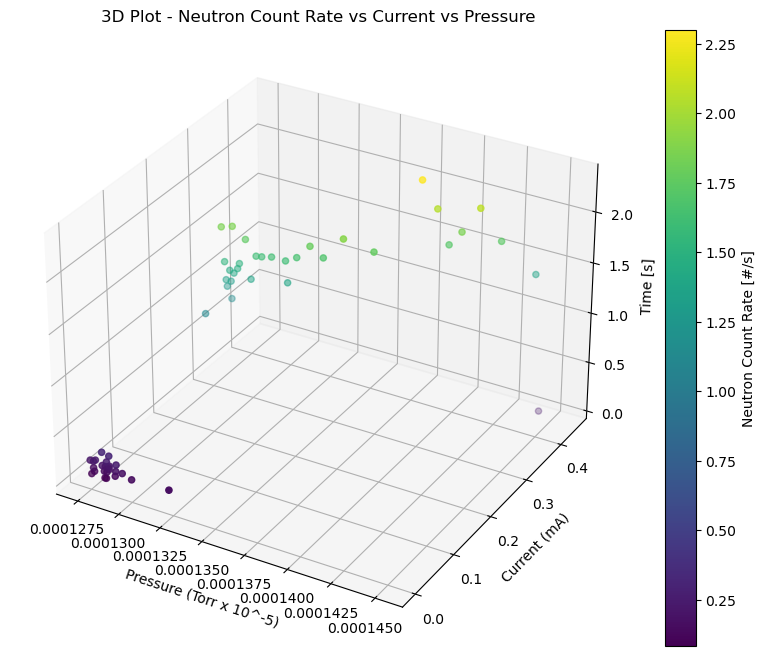

In [79]:
from mpl_toolkits.mplot3d import Axes3D

pressure_values = dp['smoothed_pressure']

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data in 3D
sc = ax.scatter(averaged_pressure, averaged_current, rates, c=rates, cmap='viridis', marker='o', s=20)

ax.set_xlabel(f'Pressure (Torr x 10^{exponent})')
ax.set_ylabel('Current (mA)')
ax.set_zlabel('Time [s]')
ax.set_title('3D Plot - Neutron Count Rate vs Current vs Pressure')

# Add a color bar indicating neutron count rate
cbar = plt.colorbar(sc)
cbar.set_label('Neutron Count Rate [#/s]')

# Show the plot
plt.show()


In [61]:
# Get count histogram (and bins) for on/off periods

ecell_on_results = [trial.condition_rate_time_series(dwell_time) 
                    for trial in trials]
ecell_off_results = [trial.background_rate_time_series(dwell_time)
                     for trial in trials]

ecell_on_period_cps, ecell_on_period_error, ecell_on_period_bins = list(zip(*ecell_on_results))
ecell_off_period_cps, ecell_off_period_error, ecell_off_period_bins = list(zip(*ecell_off_results))

ecell_on_cps, ecell_on_bins = combine_period_histograms(ecell_on_period_cps, 
                                                           ecell_on_period_bins)
ecell_on_error, _ = combine_period_histograms(ecell_on_period_error,
                                             ecell_on_period_bins)
ecell_off_cps, ecell_off_bins = combine_period_histograms(ecell_off_period_cps, 
                                                             ecell_off_period_bins)
ecell_off_error, _ = combine_period_histograms(ecell_off_period_error,
                                              ecell_off_period_bins)

# np_start_datetime = np.datetime64(caen_start_datetime)
# ecell_on_bins_time = (ecell_on_bins*1E-6).astype('timedelta64[us]')
# ecell_on_bins_time = (ecell_on_bins_time + np_start_datetime).astype(datetime)
# ecell_off_bins_time = (ecell_off_bins*1E-6).astype('timedelta64[us]')
# ecell_off_bins_time = (ecell_off_bins_time + np_start_datetime).astype(datetime)
ecell_on_bins_time = ecell_on_bins*1E-12/60
ecell_off_bins_time = ecell_off_bins*1E-12/60

NameError: name 'trials' is not defined

In [40]:
# Plot rates over time, labelled by condition/background

fig, ax = plot_histogram(
    [ecell_on_bins_time, ecell_off_bins_time],
    [ecell_on_cps, ecell_off_cps],
    labels=[on_display_name, off_display_name],
    errors=[ecell_on_error, ecell_off_error]
)

fig.suptitle("Neutron Count Rate over Experiment Time", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_title(f"Binning: {dwell_time} seconds", fontsize=10)
ax.set_ylabel("Neutron Count Rate (1/s)", fontsize=10)
ax.set_xlabel("Time (min)", fontsize=10)
fig.tight_layout()
plt.subplots_adjust(top=0.88)

fig.savefig(REPORT_ROOT / 'count_rates_over_time_ID.png')

NameError: name 'ecell_on_bins_time' is not defined

In [41]:
# Define dwell time (in seconds)
dwell_time = 60

### Trial CPS Histograms

In [138]:
# Function definition
def get_mean_rate_from_histogram(
    counts: np.ndarray, 
    bin_bounds: np.ndarray
) -> float:
    bin_widths = np.diff(bin_bounds)
    bin_low_bounds = bin_bounds[:-1]
    bin_midpoint_rates = bin_widths / 2 + bin_low_bounds
    
    weighted_rates = counts*bin_midpoint_rates
    total_weighted_rate = np.sum(weighted_rates, axis=None)
    total_count = np.sum(counts, axis=None)
    mean_rate = total_weighted_rate / total_count
    return mean_rate

In [139]:
# Plot CPS histogram for each trial

dwell_time = 30
ideal_columns = 3  # TODO reset to 4 once method below is made
cps_n_bins = 20

# TODO need method for subplot arrangement
# goals: fit n plots into a r x c grid where r x c > n, 
# where perimiter of grid is minimized, 
# where c <= 4, and where r x c - n is minimized
# input: number of trials, subplots formatting kwargs
# output: figure, flattened axes list
exp_count = len(trials)
columns = min(exp_count, ideal_columns)
rows = -(-exp_count // ideal_columns)

fig, axs = plt.subplots(rows, columns, squeeze=False, figsize=(12, 6))
axs_flattened = [ax for row in axs for ax in row]
if rows * columns != exp_count:
    for unused_ax in axs_flattened[exp_count:]:
        fig.delaxes(unused_ax)

for i, (ax, trial) in enumerate(list(zip(axs_flattened, trials))):
    cond_counts, cond_bin_bounds = trial.condition_rate_histogram(
        dwell_time, cps_n_bins)
    bg_counts, bg_bin_bounds = trial.background_rate_histogram(
        dwell_time, cps_n_bins)
    
    cond_rates, _, _ = trial.condition_rate_time_series(dwell_time)
    bg_rates, _, _ = trial.background_rate_time_series(dwell_time)
    sigma_cond_rate = np.std(cond_rates)
    sigma_bg_rate = np.std(bg_rates)
    
    mean_cond_rate = get_mean_rate_from_histogram(
        cond_counts, cond_bin_bounds)
    mean_bg_rate = get_mean_rate_from_histogram(
        bg_counts, bg_bin_bounds)
    
    print(f"Trial {i+1}:")
    print(f"Weighted mean condition rate: {mean_cond_rate:.4f}, SD: {sigma_cond_rate:.4f}")
    print(f"Weighted mean background rate: {mean_bg_rate:.4f}, SD: {sigma_bg_rate:.4f}")

    stairs_format = dict(lw=2, alpha=0.25, fill=True)
    ax.stairs(cond_counts, cond_bin_bounds, 
              label=on_display_name, 
              **stairs_format)
    ax.stairs(bg_counts, bg_bin_bounds, 
              label=off_display_name, 
              **stairs_format)
    
    ylim_lo, ylim_hi = ax.get_ylim()
    best_x_lim = ax.get_xlim()
    bg_sigma_y = 0.1 * (ylim_hi - ylim_lo) + ylim_lo
    cond_sigma_y = 0.2 * (ylim_hi - ylim_lo) + ylim_lo
    
    lines_format = dict(colors=["C0", "C1"], 
                        linestyles='solid', 
                        linewidth=3)
    ax.vlines([mean_cond_rate, mean_bg_rate], 
              ylim_lo, ylim_hi, 
              **lines_format)
    ax.hlines([cond_sigma_y, bg_sigma_y],
              [mean_cond_rate - sigma_cond_rate, 
               mean_bg_rate - sigma_bg_rate],
              [mean_cond_rate + sigma_cond_rate, 
               mean_bg_rate + sigma_bg_rate],
              **lines_format)
#     ax.set_xlim(*best_x_lim)  # Fix x limits when sigma is too big
    
    ax.set_xlabel("Neutron Count Rates (1/s)", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.set_title(f"Trial {i+1}")
    ax.legend()
    
plt.suptitle(f"Neutron Count Rate Distributions\nDwell Time {dwell_time} seconds")
fig.tight_layout(pad=1.0)

fig.savefig(REPORT_ROOT / 'count_rate_distributions.png')

NameError: name 'trials' is not defined

In [140]:
end_dt = datetime.now()
elapsed = end_dt - start_dt
print(f"Total run time: {elapsed.total_seconds():.3f} s")

Total run time: 282.721 s
